# Running Simulations with the MIDA Head Phantom

## Introduction

The purpose of this notebook is to demonstrate how to run CT simulations using open-source head phantoms as a part of **Aim 1.3** with the [XCIST](https://github.com/xcist/main) CT simulation framework.

![](../project_aims.png)
*This notebook focuses on Aim 1.3, CT Dataset Generation Pipeline*

### Previous Work

Previously for the [pilot study](https://github.com/bnel1201/Virtual-Patient-CT-Simulations/blob/PedSilicoICH-Pilot/pedsilico-pilot.ipynb) we demonstrated inserting simple circular lesions into an XCAT head phantom using the [XCIST simulation framework](https://github.com/xcist). See their [Phys Med Bio article](https://iopscience.iop.org/article/10.1088/1361-6560/ac9174) for more.

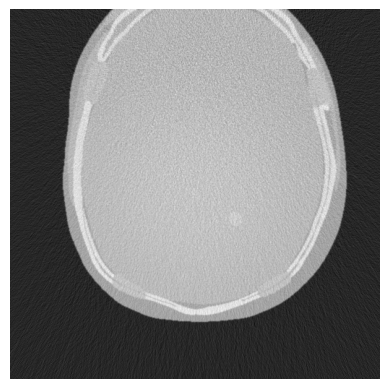

###  Why Virtual Imaging Trials?

Data driven methods like AI have enabled innovation in medical devices and clinical practice by leveraging large data sources to solve previously intractable problems in medical imaging including image reconstruction, segmentation and classification. However, any data driven method is at risk of bias and over fitting on sparse and noisey training sets and are liable to drift to changing data sources in production. Developing large, diverse high quality test sets is an important mitigation to model bias and drift but becomes challenging when considering including rare diseases and underrepresented groups such as pediatrics into device development and evaluation. In addition, pediatrics have special protections on data access further challenging their inclusing in training and testing datasets. Thus in silico modeling of patients, diseases, and imaging systems will be another essential mitigation factor enabling high quality labeled data where ground truth is known exactly and can be produced sustainably compared to traditional clinical trials and retrospective collection. 

This work aims to devloped in silico disease models of large vessel occlusions that can be modeled for pediatric evaluation of LVO cadt devices.


## Methods

### Define the base healthy phantom head to be imaged

This notebook introduces running simulations with [MIDA head phantom](https://www.fda.gov/medical-devices/science-and-research-medical-devices/mida-multimodal-imaging-based-model-human-head-and-neck), a segmented MRI head model consisting of over 100 + segmented regions. The dataset is assumed to be downloaded in repository's root directory but you can modifiy `phantom_dir` accordingly if you have it else where

#### MIDA Head

In [1]:
!ls "../MIDA Head Phantom"

'MIDA RST page.url'   MIDA_slicer_preview.png   MIDA_v1.nii   MIDA_v1.txt


The directory has the voxelized segmentation volume `MIDA_v1.nii` and the lookup table with segmentation labels for each voxel value `MIDA_v1.txt`.

Let's look at the voxelized segmented volume:

Unique voxel values in this slice: [  1.   6.   7.   8.  10.  12.  17.  24.  25.  27.  32.  37.  43.  50.
  51.  52.  53.  54.  61.  62.  63.  64.  98. 116.]


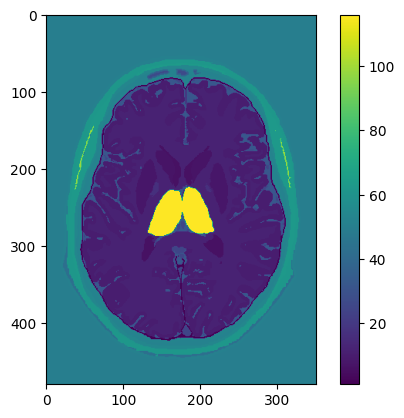

In [2]:
from pathlib import Path

import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

mida_dir = Path('../MIDA Head Phantom')
img = nib.load(mida_dir/'MIDA_v1.nii')
phantom = np.array(img.get_fdata()).transpose(1, 0, 2)
phantom_slice = phantom[300]
plt.imshow(phantom[300])
plt.colorbar()
print(f'Unique voxel values in this slice: {np.unique(phantom_slice)}')

Note that these voxel values are just segmentation labels rather than physical values. Below is the look up table for each segment, loaded from `MIDA_v1.txt`, note the top half of the file has the voxel grayscale values in the first column and material name in the last column. The bottom of the file has the image matrix size and dimensions which we'll also extract for running the CT simulation.

In [3]:
!cat "../MIDA Head Phantom/MIDA_v1.txt"

1	0	0.988235	1	Dura
2	1	0.780392	0	Cerebellum Gray Matter
3	0.658824	1	1	Pineal Body
4	0	0	1	Amygdala
5	1	0.423529	1	Hippocampus
6	0.368627	0.588235	0.54902	CSF Ventricles
7	0	0.384314	0.466667	Caudate Nucleus
8	0.823529	0.54902	1	Putamen
9	0.713726	0.121569	0.341176	Cerebellum White Matter
10	0.521569	0.521569	0.533333	Brain Gray Matter
11	0.807843	0	1	Brainstem Midbrain
12	1	1	1	Brain White Matter
13	0.917647	0.521569	0	Spinal Cord
14	1	1	0	Brainstem Pons
15	0.686275	1	0.423529	Brainstem Medulla
16	0.890196	0.905882	0	Nucleus Accumbens
17	0.894118	0.796078	1	Globus Pallidus
18	0	1	0	Optic Tract
19	1	0.686275	0	Hypophysis or Pituitary Gland
20	1	1	0	Mammillary Body
21	0.890196	0.356863	0.505882	Hypothalamus
22	0.72549	0.807843	1	Commissura (Anterior)
23	0.85098	0	0.247059	Commissura (Posterior)
24	1	0	0	Blood Arteries
25	0	0	1	Blood Veins
26	0	0	0	Air Internal - Ethmoidal Sinus
27	0	0	0	Air Internal - Frontal Sinus
28	0	0	0	Air Internal - Maxillary Sinus
29	0	0	0	Air Internal - Spheno

Thus to prepare the MIDA phantom for XCIST simulations we'll add a column called `xcist material` such that we can group several specific MIDA segmentation labels under a common, more broad label and assign it the same CT number. For example there are several anatomic regions in the MIDA phantom that are all primarily gray matter so we will assign them the xcist label of 'gray_matter' and given them a common CT number, see here for some reasonable CT numbers of materials: https://en.wikipedia.org/wiki/Hounsfield_scale#Values_for_different_body_tissues_and_material

*Note: these CT numbers are estimates and are just for making the volume fraction maps, they will differ in the final simulation depending on the chose kVp settings.*

Now we'll filter down the material look up table (LUT) just to materials with CT numbers that we've defined

Now reassign every voxel in the phantom to the defined CT numbers to make an approximate ground truth CT phantom:

/home/brandon.nelson/Dev/PedSilicoICH/src/pedsilicoICH/ground_truth_definition/phantoms.py:113: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  material_lut.loc[material_lut.material == 'Cerebellum  Gray Matter', 'xcist material'] = 'gray_matter'
/home/brandon.nelson/Dev/PedSilicoICH/src/pedsilicoICH/ground_truth_definition/phantoms.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  material_lut.loc[material_lut.material == 'Cerebellum  Gray Matter', 'CT Number [HU]'] = self.gm_HU


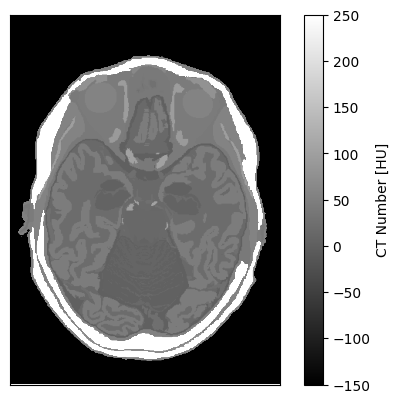

In [4]:
from pathlib import Path
from utils import ctshow

from pedsilicoICH.ground_truth_definition.phantoms import MIDA_Head

MIDA_dir = Path('../MIDA Head Phantom')
mida = MIDA_Head(MIDA_dir)
phantom = mida.get_CT_number_phantom()

im = ctshow(phantom[250])
plt.colorbar(im, label='CT Number [HU]')

In [5]:
mida_shape = phantom.shape
mida_shape

(480, 480, 350)

#### NIHPD Brain Atlas

See [02_MRI_brain_atlas_groundtruth.ipynb](02_MRI_brain_atlas_groundtruth.ipynb) for more.

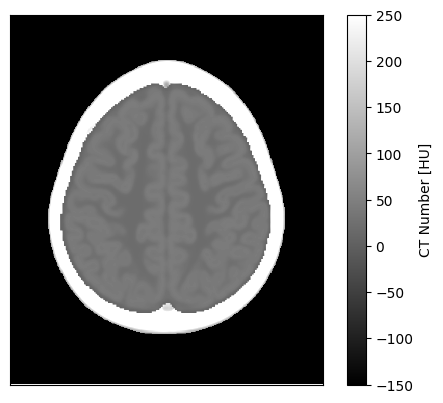

In [6]:
from pedsilicoICH.ground_truth_definition.phantoms import NIHPD_Head

nihpd_ages = [6.5, 9.0, 10.5, 11.5, 12.0, 15.75]
age = 6.5

nihpd_dir = Path('/gpfs_projects/brandon.nelson/pedsilicoICH/brain_atlases/obj1_analyze/')
nihpd = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)
phantom = nihpd.get_CT_number_phantom()

im = ctshow(phantom[250])
plt.colorbar(im, label='CT Number [HU]')

In [7]:
phantom.shape

(389, 480, 406)

#### Select Phantom Based on Age

In [8]:
mida_age = 38  # add 38 as the median US adult age to represent MIDA, consider other identifiers when adding more patients
possible_ages = nihpd_ages + [mida_age] 
possible_ages

[6.5, 9.0, 10.5, 11.5, 12.0, 15.75, 38]

12.0


Text(0.5, 1.0, '12.0')

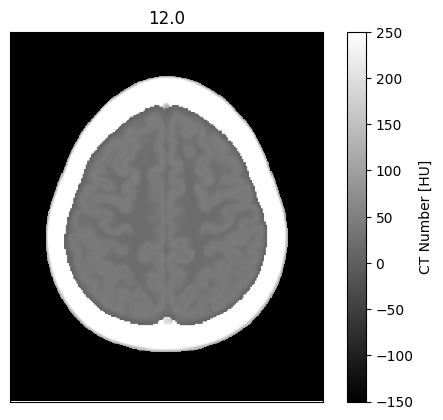

In [9]:
from random import choice

age = choice(possible_ages)
# age = 6.5
print(age)

if age == mida_age:
    phantom = MIDA_Head(mida_dir)
else:
    phantom = NIHPD_Head(nihpd_dir, age=age, shape=mida_shape)

ground_truth = phantom.get_CT_number_phantom()

midslice = 2*ground_truth.shape[0]//3
im = ctshow(ground_truth[midslice])
plt.colorbar(im, label='CT Number [HU]')
plt.title(f'{age}')

### Input Format for Running XCIST CT Simulations

According to the XCIST instructions for running CT simulations from [voxelized ground truth phantoms](https://github.com/xcist/phantoms-voxelized), XCIST requires volume fraction maps, see [their github for examples](https://github.com/xcist/phantoms-voxelized/tree/main/CatSimLogo_1024). XCIST provides [example code](https://github.com/xcist/phantoms-voxelized/blob/main/DICOM_to_voxelized/DICOM_to_voxelized_phantom.py) of how to convert CT images into these ground truth volume fraction maps.

The `CTobj` class was created as a wrapper object to simplify loading voxelized numpy ndarrays into XCIST siumulations, see the doc string for more details on use and parameters:

In [10]:
from pedsilicoICH.image_acquisition import CTobj
CTobj?

Init signature:
CTobj(
    phantom: numpy.ndarray,
    spacings: tuple,
    patientname='default',
    patientid=0,
    age=0,
    studyname='default',
    studyid=0,
    seriesname='default',
    seriesid=0,
    framework='CATSIM',
    output_dir=None,
    materials: dict | None = None,
) -> None
Docstring:     
A class to hold CT simulation data and run simulations

:param phantom: 3D phantom volume to be scanned, voxels in units of
    approximate CT Numbers [HU], typically in python coordinates (z, x, y)
    where z is perpendicular to the axial plane made by x and y.
    See <https://en.wikipedia.org/wiki/Hounsfield_scale#Values_for_different_body_tissues_and_material> for some suggested values for common materials
:param spacings: tuple of voxel sizes of phantom volume in mm (dz, dx, dy)
:param patientname: patient identifier to be saved in DICOM header
:param patientid: int, patient identifier to be saved in DICOM header
:param age: float, in years to be saved in DICOM header
:p

My goal is to reproduce the steps done here: [open source XCIST demo](https://github.com/bnel1201/XCIST_demo/blob/main/opensource_peds_demo.ipynb) of assigning each labeled anatomy to an xcist material for converting to linear attenuation units. Note that the `CTobj` constructor has two required inputs:

1. a voxelized `phantom` input in units of CT numbers
2. voxel dimensions in [mm]

The MIDA phantom consists of many segmented regions, more than we reasonably need for a CT simulation:

Now interactively view the ground truth phantom to inspect it:

In [11]:
from utils import scrollview
scrollview(ground_truth)

interactive(children=(IntSlider(value=194, description='idx', max=388), Output()), _dom_classes=('widget-inter…

## Introduce Random Affine Augmentations

To simulate a small amount of patient positioning variability

In [12]:
!python -c "import monai" || pip install -q "monai-weekly[pillow,tqdm]"

In [13]:
from monai.transforms import RandAffine

In [14]:
randaffine = RandAffine(prob=0.5, rotate_range = [np.pi/4, np.pi/20, np.pi/20], translate_range=[10, 10, 10], scale_range=[0.1, 0.1, 0.1], padding_mode="border")

scrollview(randaffine(ground_truth[None])[0])

interactive(children=(IntSlider(value=194, description='idx', max=388), Output()), _dom_classes=('widget-inter…

TODO: if CT numbers seem off, I can look into updating the thresholds in the [config file](https://github.com/xcist/phantoms-voxelized/blob/main/DICOM_to_voxelized/DICOM_to_voxelized_example_head.cfg) appropriately to get the best match in CT numbers (could do something like grab the unique values since I'm starting from ground truth, they are [currently configured](https://github.com/brandonjnelsonFDA/PedSilicoICH/blob/master/src/pedsilicoICH/ground_truth_definition/phantoms.py#L23) for abdominal imaging, rather than head.

Example of [normal brain CT](https://nbia.cancerimagingarchive.net/viewer/?study=1.3.6.1.4.1.14519.5.2.1.3098.5025.922017993220231365363448902707&series=1.3.6.1.4.1.14519.5.2.1.3098.5025.127673560102649811051571885155&token=eyJhbGciOiJIUzI1NiIsInR5cCIgOiAiSldUIiwia2lkIiA6ICJkZGFhMGY3YS1kZTBmLTRkYWQtYjM1ZS05MjljYjBiMTY3YjgifQ.eyJleHAiOjE3MDQ0MDA4NDYsImlhdCI6MTcwNDM5MzY0NiwianRpIjoiZDU4YTI0M2YtNGQwZi00MjljLTg0NDQtMGI5MjJjNzUzNWQ0IiwiaXNzIjoiaHR0cHM6Ly9rZXljbG9hay5kYm1pLmNsb3VkL2F1dGgvcmVhbG1zL1RDSUEiLCJhdWQiOiJhY2NvdW50Iiwic3ViIjoiZjowMTliNTYzNC1kYWJkLTQyMTEtYTQxZC03MjNjNDRhZmNmZmQ6bmJpYV9ndWVzdCIsInR5cCI6IkJlYXJlciIsImF6cCI6Im5iaWEiLCJzZXNzaW9uX3N0YXRlIjoiYzc5OTIxMTItZjcyYS00OWY5LWI0ZTMtOWY3ZTFmN2I0NzQ5IiwiYWNyIjoiMSIsImFsbG93ZWQtb3JpZ2lucyI6WyJodHRwczovL3NlcnZpY2VzLmNhbmNlcmltYWdpbmdlYXJjaGl2ZS5uZXQiLCJodHRwczovL25iaWEuY2FuY2VyaW1hZ2luZ2VhcmNoaXZlLm5ldCIsImh0dHBzOi8vd3d3LmNhbmNlcmltYWdpbmdlYXJjaGl2ZS5uZXQiLCIqIiwiaHR0cDovL3RjaWEtbmJpYS0yLmFkLnVhbXMuZWR1OjQ1MjEwIiwiaHR0cHM6Ly9jYW5jZXJpbWFnaW5nZWFyY2hpdmUubmV0IiwiaHR0cDovL3RjaWEtbmJpYS0xLmFkLnVhbXMuZWR1OjQ1MjEwIiwiaHR0cHM6Ly9wdWJsaWMuY2FuY2VyaW1hZ2luZ2VhcmNoaXZlLm5ldCJdLCJyZWFsbV9hY2Nlc3MiOnsicm9sZXMiOlsib2ZmbGluZV9hY2Nlc3MiLCJkZWZhdWx0LXJvbGVzLXRjaWEiLCJ1bWFfYXV0aG9yaXphdGlvbiJdfSwicmVzb3VyY2VfYWNjZXNzIjp7ImFjY291bnQiOnsicm9sZXMiOlsibWFuYWdlLWFjY291bnQiLCJtYW5hZ2UtYWNjb3VudC1saW5rcyIsInZpZXctcHJvZmlsZSJdfX0sInNjb3BlIjoib3BlbmlkIHByb2ZpbGUgZW1haWwiLCJzaWQiOiJjNzk5MjExMi1mNzJhLTQ5ZjktYjRlMy05ZjdlMWY3YjQ3NDkiLCJlbWFpbF92ZXJpZmllZCI6dHJ1ZSwibmFtZSI6Ik5CSUEgR3Vlc3QiLCJwcmVmZXJyZWRfdXNlcm5hbWUiOiJuYmlhX2d1ZXN0IiwiZ2l2ZW5fbmFtZSI6Ik5CSUEiLCJmYW1pbHlfbmFtZSI6Ikd1ZXN0IiwiZW1haWwiOiJuYmlhX2d1ZXN0QGNhbmNlcmltYWdpbmdhcmNoaXZlLm5ldCJ9.q7c8o4AZK8cnCMYmZD_TjGvGyLIAZBysMJNIVV3agrE) for reference:

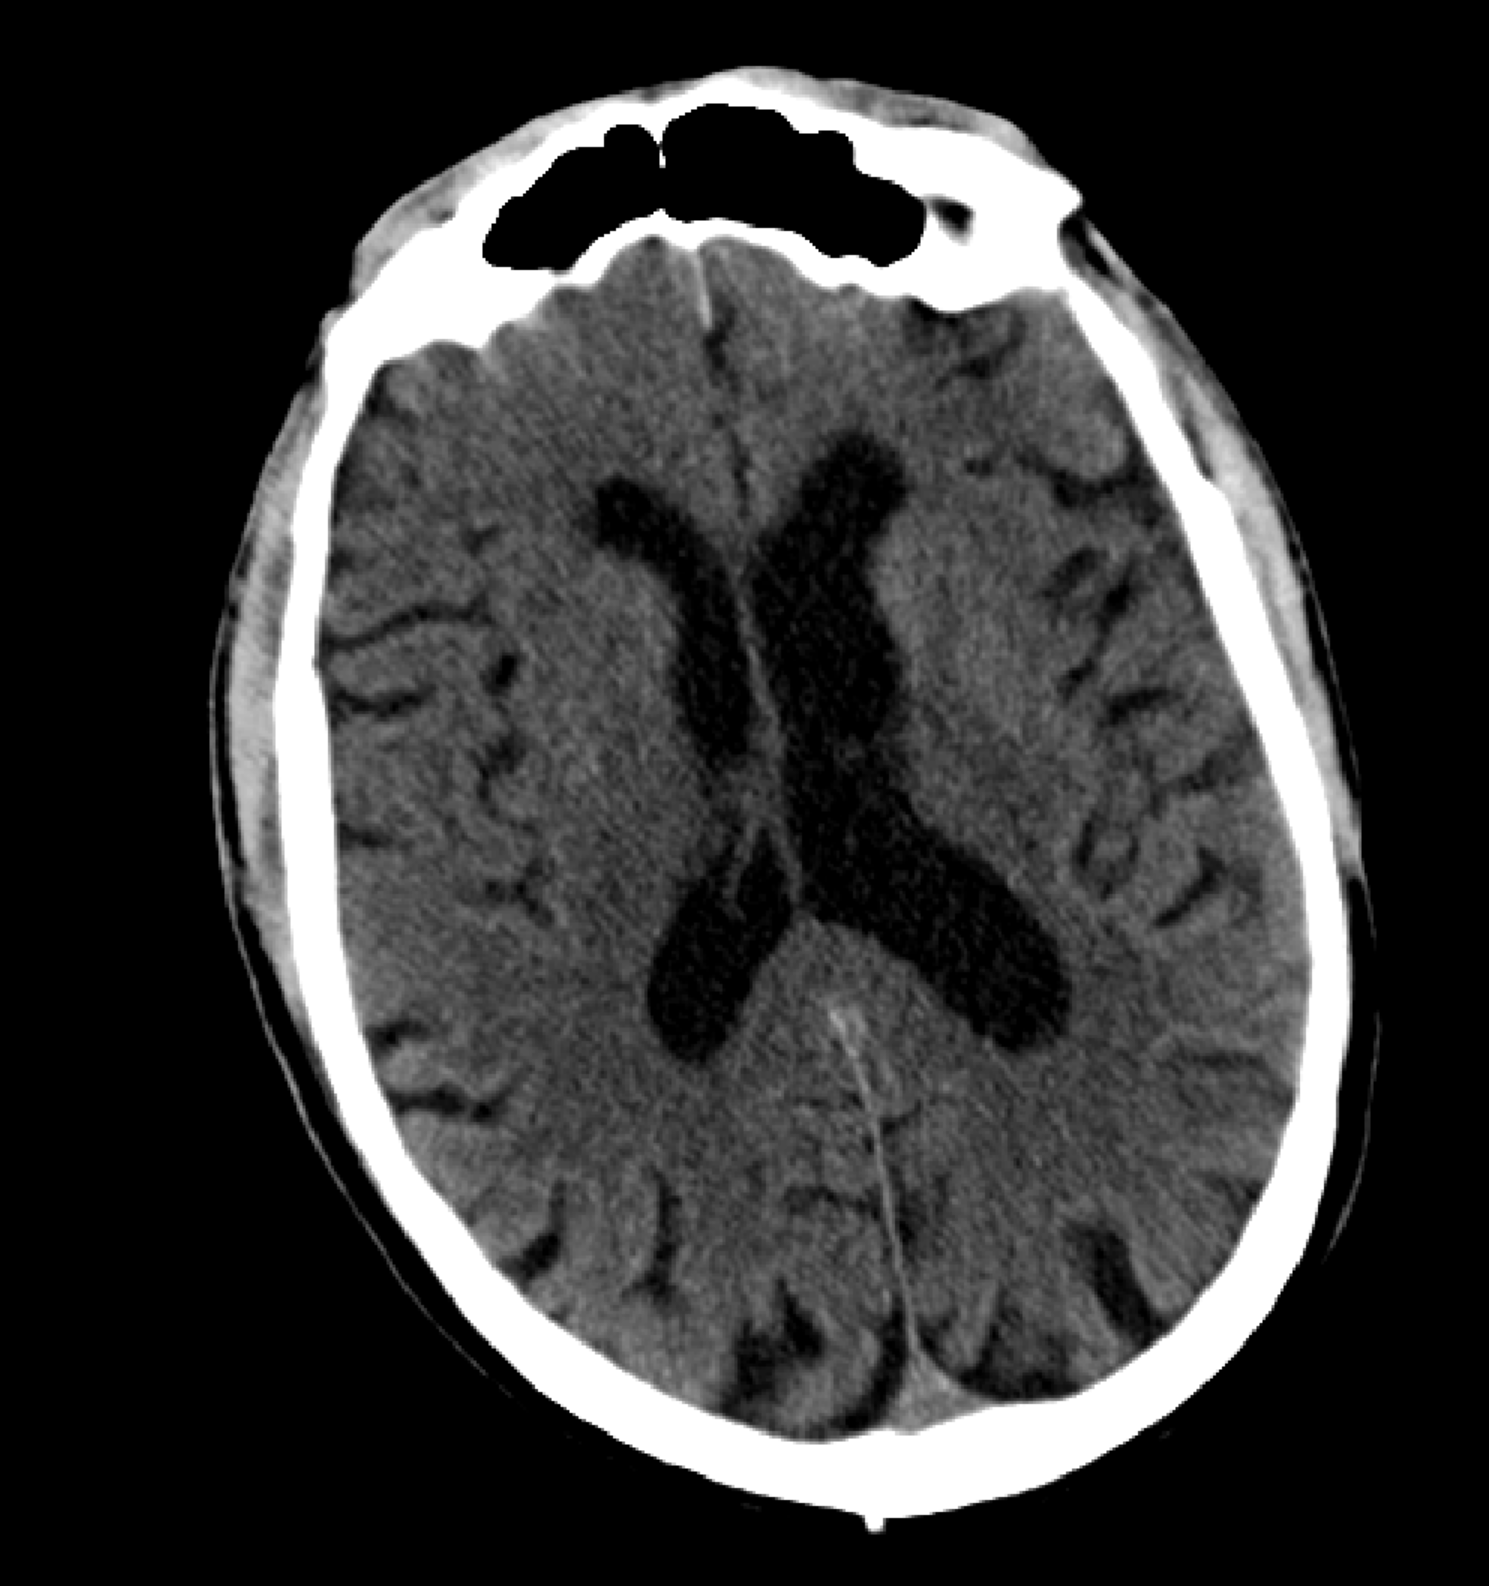

### Now add a lesion

Some simple analytical geometric lesions are included in the module `lesion_insertion`

In [15]:
from pedsilicoICH.lesion_insertion import add_random_sphere_lesion

In [16]:
add_random_sphere_lesion?

Signature:
add_random_sphere_lesion(
    vol: numpy.ndarray,
    mask: numpy.ndarray,
    radius: list[int] = [20],
    contrast: list[int] = [-100],
) -> tuple
Docstring:
adds lesion to vol in random location within mask of size radius
and contrast level contrast

:param vol: array to insert lesion into
:param mask: mask that specifies limits inside the `vol` of
    potential insertion locations
:param radius: int or list of ints, radius of the sphere lesion,
    if provided a list it will make concentric lesions
:param contrast: int or list of ints, contrast of the sphere lesion,
    if provided a list it will make concentric lesions of contrasts

:returns: img_w_lesion, lesion_vol, (z, x, y)
File:      ~/Dev/PedSilicoICH/src/pedsilicoICH/lesion_insertion.py
Type:      function

Below I specify the material that I wish to use to make the mask for where I want the lesion randomly inserted in to.

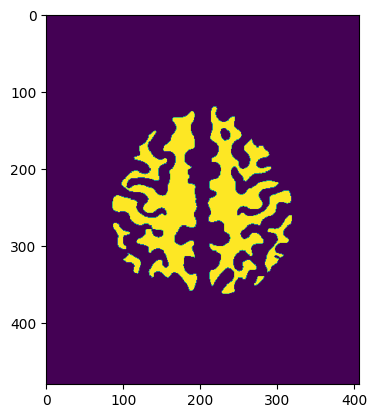

In [17]:
material = 'white matter'
mask = phantom.get_material_mask(material)

plt.imshow(mask[midslice])

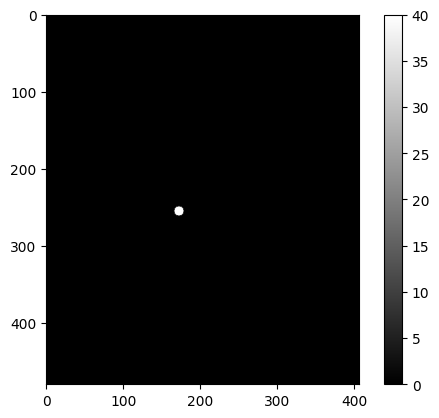

In [18]:
radius = 6
contrast = 40
             
img_w_lesion, lesion_image, lesion_coords = add_random_sphere_lesion(ground_truth, mask.astype(int), radius=radius, contrast=contrast)
plt.imshow(lesion_image[lesion_coords[0]], cmap='gray')
plt.colorbar()

Some hemorrhages develop hypoattenuating edema or fluid build up following healhing.

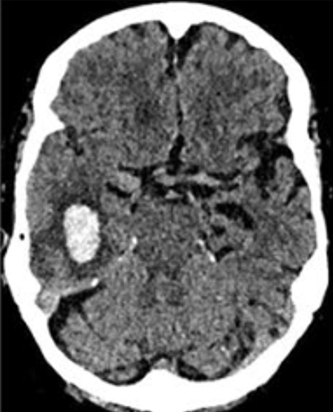

We can add in annuli of different contrasts mimicing lesions by specifying a list of radii and contrasts:

(np.int64(81), np.int64(292), np.int64(175))


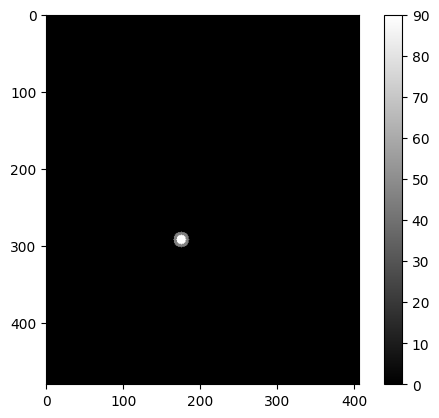

In [19]:
radius = [6, 10]
contrast = [50, -5]
              
img_w_lesion, lesion_image, lesion_coords = add_random_sphere_lesion(ground_truth, mask, radius=radius, contrast=contrast)
print(lesion_coords)
plt.imshow(lesion_image[lesion_coords[0]], cmap='gray')
plt.colorbar()

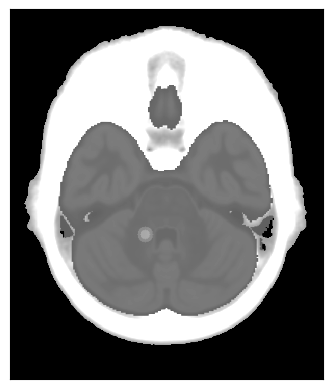

In [20]:
ctshow(img_w_lesion[lesion_coords[0]])

In [21]:
scrollview(img_w_lesion)

interactive(children=(IntSlider(value=194, description='idx', max=388), Output()), _dom_classes=('widget-inter…

In [22]:
from pedsilicoICH.artifact_generation import transform_image_label_pair

add_positioning_augmentation = True
if add_positioning_augmentation:
    positioning_transform = RandAffine(prob=0.5, rotate_range = [np.pi/4, np.pi/20, np.pi/20], translate_range=[10, 10, 10], scale_range=[0.1, 0.1, 0.1], padding_mode="border")
else:
    positioning_transform = RandAffine(prob=0)

img_transform, lesion_transform = transform_image_label_pair(positioning_transform, img_w_lesion, lesion_image, seed=42)

Text(0.5, 1.0, 'Transformed')

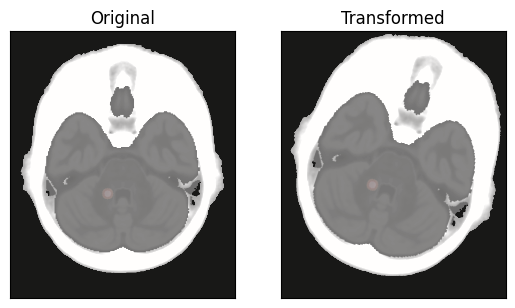

In [23]:
f, axs = plt.subplots(1,2)
ctshow(img_w_lesion[lesion_coords[0]], fig=f, ax=axs[0])
axs[0].imshow(lesion_image[lesion_coords[0]], alpha=0.1, cmap='Reds')
axs[0].set_title('Original')

ctshow(img_transform[lesion_coords[0]], fig=f, ax=axs[1])
axs[1].imshow(lesion_transform[lesion_coords[0]], alpha=0.1, cmap='Reds')
axs[1].set_title('Transformed')

In [24]:
ctobj_lesion = CTobj(img_transform, spacings=(phantom.dz, phantom.dx, phantom.dy), patientname='small phantom with lesion')

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 0.48541666666666666-mm pixels (XY), 0.48586118251928023-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ICRU_lung_adult_healthy', 'ICRU_adipose_adult2', 'water', 'ICRU_liver_adult', 'ICRU_skeleton_cortical_bone_adult']
* mu values (/cm): [0.05, 0.19, 0.21, 0.22, 0.6]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.0, 0.16, 0.21, 0.23, 0.27]
* Thresholds (HU): [-1000.0, -200.0, 0.0, 100.0, 300.0]
*********************************************
* Calculating volume fraction maps for 5 materials and 389 slices...
* Writing volume f

Based on the size of the phantom we can get an estimate of how many scans are required to cover it, from there we can either keep the full range or modify accordingly, we can also set the table speed if we want to use helical acquisition for faster scan times (although I don't yet have helical acquisitions figured out yet, see [github issue](https://github.com/xcist/main/issues/73) on this and the [helical mode example](https://github.com/xcist/main/blob/master/gecatsim/examples/Sim_Sample_Helical.py).

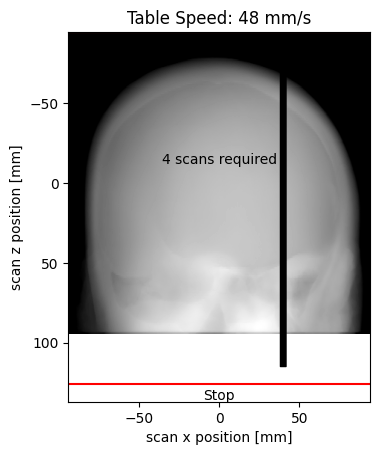

In [25]:
ctobj_lesion.scout_view(table_speed='Intermediate')

In [26]:
ctobj_lesion.recommend_scan_range?

Signature: ctobj_lesion.recommend_scan_range(threshold=-950) -> tuple
Docstring:
returns recommended startZ and endZ based on scout scan
attenuation profile

threshold [HU] determines minimum attenuating regions to keep
File:      ~/Dev/PedSilicoICH/src/pedsilicoICH/image_acquisition.py
Type:      method

recommended range: (-75.06555269922879, 70.7842105263158) mm


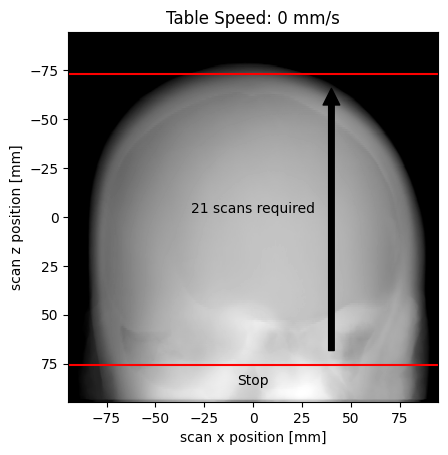

In [27]:
suggested_start_mm, suggested_end_mm = ctobj_lesion.recommend_scan_range()
print(f'recommended range: ({suggested_start_mm}, {suggested_end_mm}) mm')
ctobj_lesion.scout_view(startZ=suggested_start_mm, endZ=suggested_end_mm)

Arrow indicates table direction, it translates here with the base of the skull moving vertically

For a quick test let's do 1 scan so adjust the extent accordingly

Convert the lesion Z level from pixel coordinates to the table coordinates so we can selectively scan around the lesion for faster run times for this demo.

In [28]:
lesion_level_mm = (img_transform.shape[0]/2 - lesion_coords[0])*phantom.dz
lesion_level_mm

np.float64(55.145244215938305)

55.145244215938305 47.145244215938305 63.145244215938305


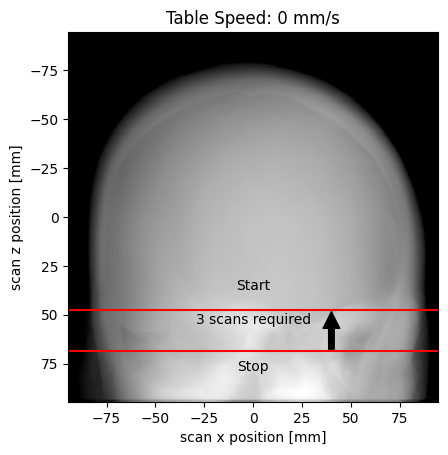

In [29]:
center = lesion_level_mm
width = 16

startZ = center - width//2
endZ = startZ + width

print(center, startZ, endZ)
ctobj_lesion.scout_view(startZ=startZ, endZ=endZ, table_speed=0)

Look at how much faster we can scan with helical mode!

Still unclear how to do recon in helical mode...

there is 
```python
ctobj_lesion.xcist.cfg.recon.reconType = 'helical_equiAngle'
```

as discussed here: https://github.com/xcist/main/issues/61#issuecomment-1955840993



In [30]:
ctobj_lesion.xcist.cfg.protocol.tableSpeed

0

In [ ]:
ctobj_lesion.run_scan(mA=500, startZ=startZ, endZ=endZ, views=100)

scan: 1/3
Airscan
Offset scan
Phantom scan
phantom scan view loop...


  0%|                                                                                           | 0/100 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated memory for image volume for material  5
in C> Copying data for material  5 into C memory...in C>  done.
in C> Allocated a total of   1445 MB.


 25%|████████████████████▌                                                             | 25/100 [00:48<01:41,  1.36s/it]

In [ ]:
ctobj_lesion.run_recon(sliceThickness=1)

ctobj_lesion.xcist.cfg.recon.reconType = 'helical_equiAngle'
ctobj_lesion.xcist.cfg.recon.reconType

ctobj_lesion.xcist.cfg.recon.sliceThickness = 1
ctobj_lesion.xcist.cfg.recon.sliceCount = int(ctobj_lesion.scan_width / ctobj_lesion.xcist.cfg.recon.sliceThickness)
ctobj_lesion.run_recon(sliceCount=40)

In [ ]:
scrollview(ctobj_lesion.recon)

In [ ]:
mask = ctobj_lesion.get_lesion_mask(lesion_transform, startZ=startZ, endZ=endZ)

In [ ]:
idx = 7
f, axs = plt.subplots(1, 2, dpi=150)
ctshow(ctobj_lesion.recon[idx], fig=f, ax=axs[0])
ctshow(ctobj_lesion.recon[idx], fig=f, ax=axs[1])
axs[1].imshow(mask[idx], alpha=0.15, cmap='Reds')
axs[0].set_title('CT Image')
axs[1].set_title('Lesion Mask Overlay')

In [ ]:
vol_mm3 = np.prod(ctobj_lesion.spacings)*mask.sum()
vol_ml = vol_mm3/1000
vol_ml

## Writing to Dicom

In [ ]:
fnames = ctobj_lesion.write_to_dicom(fname = Path(ctobj_lesion.patientname) / 'dicoms' / f'{ctobj_lesion.patientname}.dcm')
fnames

### Read in Results

In [ ]:
from pedsilicoICH.image_acquisition import read_dicom
vol = np.stack([read_dicom(o) for o in fnames])
vol.shape

In [ ]:
scrollview(vol)

lo_dose

In [ ]:
scrollview(ctobj_lesion.recon.transpose(2,1, 0))

In [ ]:
hi_dose = ctobj_lesion.recon

In [ ]:
im = ctshow(hi_dose[-1]+20, 'brain')
plt.colorbar(im)

In [ ]:
scrollview(hi_dose)

## Rescan at a lower dose

In [ ]:
mA = 500/10
mA

In [ ]:
ctobj_lesion.run_scan(mA=mA, startZ=startZ, endZ=endZ, views=100)

In [ ]:
ctobj_lesion.run_recon(fov=250)

In [ ]:
lo_dose = ctobj_lesion.recon

In [ ]:
scrollview(lo_dose)

In [ ]:
f, ax = plt.subplots(dpi=150)
im = ctshow(np.concatenate([hi_dose[-1], lo_dose[-1]], axis=1)+20, 'brain', fig=f,ax=ax)
plt.colorbar(im)
plt.title(f'Hi Dose 500 mA | Lo Dose {mA} mA') 

## Now Low kV

In [ ]:
ctobj_lesion.run_scan(mA=500, kVp=80, startZ=-50, endZ=-44, views=100)

In [ ]:
lo_kV = ctobj_lesion.recon

In [ ]:
scrollview(lo_kV)

In [ ]:
ctobj_lesion.start_positions = ctobj_lesion.calculate_start_positions()
ctobj_lesion.scout_view(startZ=startZ, endZ=endZ)

In [ ]:
ctobj_lesion.run_scan(startZ=startZ, endZ=endZ, views=100)

In [ ]:
f, ax = plt.subplots(dpi=150)
im = ctshow(np.concatenate([hi_dose[-1], lo_kV[-1]], axis=1)+20, fig=f,ax=ax)
plt.colorbar(im)
plt.title('120 kV | 80 kV') 

### Short Scan of Full Volume

In [ ]:
ctobj_lesion.start_positions = ctobj_lesion.calculate_start_positions()
ctobj_lesion.scout_view(startZ=-75, endZ=75)

In [ ]:
ctobj_lesion.run_scan(mA=500, startZ=-75, endZ=75, views=100)

In [ ]:
stacked_recon = ctobj_lesion.recon

In [ ]:
stacked_recon.shape

In [ ]:
scrollview(stacked_recon)

There should be a better way to do helical to cover more brain fast but for now I dont know how to do it...

ctobj_lesion.xcist.cfg.protocol.viewCount = 500
ctobj_lesion.xcist.protocol.stopViewId = ctobj_lesion.xcist.cfg.protocol.startViewId+ctobj_lesion.xcist.cfg.protocol.viewCount-1

ctobj_lesion.xcist.cfg.protocol.rotationTime

ctobj_lesion.xcist.cfg.protocol.viewsPerRotation = 50

ctobj_lesion.xcist.cfg.protocol.tableSpeed = 1

nrviews = ctobj_lesion.xcist.cfg.protocol.viewCount
zshifts = np.arange(nrviews)*ctobj_lesion.xcist.cfg.protocol.tableSpeed*ctobj_lesion.xcist.cfg.protocol.rotationTime/ctobj_lesion.xcist.cfg.protocol.viewsPerRotation
zshifts.shape

zshifts[0], zshifts[-1]

ctobj_lesion.xcist.run_all()

ctobj_lesion.xcist.cfg.recon.sliceCount = 40
ctobj_lesion.xcist.cfg.recon.sliceThickness = 1

from gecatsim.reconstruction.pyfiles import recon
recon.recon(ctobj_lesion.xcist.cfg)

from dxcist.xcist_sims import get_reconstructed_data
test_helical_recon = get_reconstructed_data(ctobj_lesion.xcist)
test_helical_recon.shape

scrollview(test_helical_recon)

Has something to do with setting the zshift [see here](https://github.com/xcist/main/blob/4d0e50f016558c4bb64efd413d594925d0f00570/gecatsim/dose/pyfiles/catdoserecon.py#L116). This would make it easier to redo the reconstruction across a whole volume

In [ ]:
nib.save(nib.Nifti1Image(stacked_recon, np.eye(4)), 'sparse_view_MIDA.nii')

In [ ]:
scrollview(stacked_recon.transpose(2, 0, 1))

In [ ]:
ctshow(img_transform[lesion_coords[0]])
plt.imshow(lesion_transform[lesion_coords[0]], 'Reds', alpha=0.25)

In [ ]:
from utils import center_crop, center_crop_like

In [ ]:
f, axs = plt.subplots(1,2, dpi=150)
ctshow(center_crop(img_transform[lesion_coords[0]]), fig=f, ax=axs[0])
axs[0].imshow(center_crop_like(lesion_transform[lesion_coords[0]], img_transform[lesion_coords[0]]), 'Reds', alpha=0.25)

offset=4
scaled_lesion_loc = int(np.ceil(stacked_recon[offset:].shape[0] - lesion_coords[0]/img_transform.shape[0] * stacked_recon[offset:].shape[0] + offset))
ctshow(center_crop(stacked_recon[scaled_lesion_loc]), fig=f, ax=axs[1])

In [ ]:
ctobj_lesion.recon = stacked_recon

Can use table startZ to translate and acquire repeat axial slices!

In [ ]:
import pydicom
from datetime import datetime
ctobj_lesion.write_to_dicom('test/test_lesion.dcm');

## Full View Single View

In [ ]:
ctobj_lesion.start_positions = ctobj_lesion.calculate_start_positions()
ctobj_lesion.scout_view(startZ=startZ, endZ=endZ)

In [ ]:
ctobj_lesion.run_scan(startZ=startZ, endZ=endZ, views=1000)

In [ ]:
full_scan = ctobj_lesion.recon

In [ ]:
scrollview(full_scan)

In [ ]:
ctshow(full_scan[-1]+20, 'brain')

In [ ]:
f, ax = plt.subplots(dpi=150)
im = ctshow(np.concatenate([hi_dose[-0], full_scan[-0]], axis=1)+20, 'brain', fig=f,ax=ax)
# plt.colorbar(im)
plt.title('short scan | full scan') 

## Exploring Table Speeds and Helical Recon

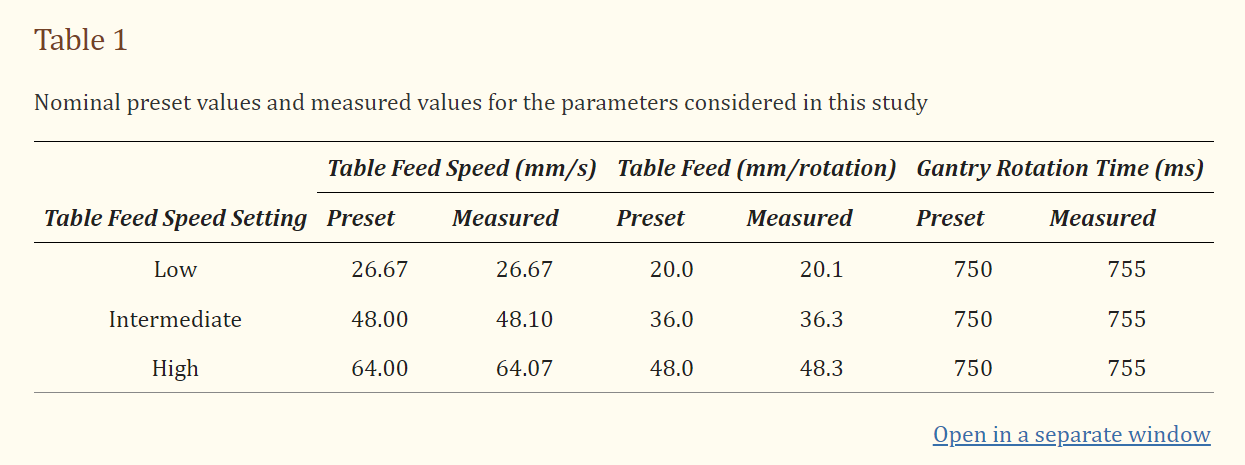

https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5711061/

In [ ]:
table_speed = 48 # medium, mm/s

In [ ]:
table_speed = {'Low': 26.67, 'Intermediate': 48, 'High': 64} # https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5711061/

Params to change: 1. views per rotation, 2. table speed, 3. total scan length

In [ ]:
ctobj_lesion.xcist.cfg.protocol.viewsPerRotation = 100
ctobj_lesion.xcist.cfg.protocol.tableSpeed = table_speed['Intermediate']
ctobj_lesion.total_scan_length, ctobj_lesion.xcist.cfg.protocol.tableSpeed, ctobj_lesion.xcist.cfg.protocol.viewsPerRotation

Don't edit below, these are the calculations

In [ ]:
zcoverage_per_scan = ctobj_lesion.xcist.cfg.protocol.rotationTime * ctobj_lesion.xcist.cfg.protocol.tableSpeed
rotations_required = ctobj_lesion.total_scan_length / zcoverage_per_scan
zcoverage_per_scan, rotations_required

In [ ]:
ctobj_lesion.xcist.cfg.protocol.tableSpeed = 0
print(len(ctobj_lesion.calculate_start_positions()))

ctobj_lesion.xcist.cfg.protocol.tableSpeed = table_speed['Low']
print(len(ctobj_lesion.calculate_start_positions()))

ctobj_lesion.xcist.cfg.protocol.tableSpeed = table_speed['Intermediate']
print(len(ctobj_lesion.calculate_start_positions()))

ctobj_lesion.xcist.cfg.protocol.tableSpeed = table_speed['High']
print(len(ctobj_lesion.calculate_start_positions()))

In [ ]:
ctobj_lesion.xcist.cfg.protocol.viewCount = np.ceil(ctobj_lesion.xcist.cfg.protocol.viewsPerRotation*rotations_required).astype(int)
ctobj_lesion.xcist.cfg.protocol.stopViewId = ctobj_lesion.xcist.cfg.protocol.startViewId + ctobj_lesion.xcist.cfg.protocol.viewCount - 1
ctobj_lesion.xcist.cfg.protocol.stopViewId 

In [ ]:
ctobj_lesion.xcist.cfg.protocol.viewCount, ctobj_lesion.xcist.cfg.protocol.viewsPerRotation, ctobj_lesion.xcist.protocol.startZ

In [ ]:
ctobj_lesion.xcist.protocol.tableSpeed

In [ ]:
ctobj_lesion.xcist.run_all()

In [ ]:
from dxcist.xcist_sims import get_projection_data, get_reconstructed_data

In [ ]:
proj = get_projection_data(ctobj_lesion.xcist)
proj.shape

In [ ]:
ctobj_lesion.xcist.cfg.recon.sliceThickness = 5
ctobj_lesion.xcist.cfg.recon.sliceCount= int(ctobj_lesion.total_scan_length // (ctobj_lesion.xcist.cfg.recon.sliceThickness/2))
ctobj_lesion.xcist.cfg.recon.sliceCount

In [ ]:
from gecatsim.reconstruction.pyfiles import recon
recon.recon(ctobj_lesion.xcist.cfg)

In [ ]:
scrollview(get_reconstructed_data(ctobj_lesion.xcist))

In [ ]:
nib.save(nib.Nifti1Image(hi_dose, np.eye(4)), 'sparse_view.nii')

In [ ]:
nib.save(nib.Nifti1Image(full_scan, np.eye(4)), 'full_view.nii')

There are viewer aliasing streaks in the full scan

## TODOS

1. [ ] fix water atten value such that CT numbers are correct (currently a small negative bias, eg brain rois around -20 HU when  they should be +20 HU)
2. [ ] Merge MIRT and CATSim as different subclasses of CTobj so its easy to switch between the two (the first step of making a ground truth phantom with attenuation coefficients is the same)
   - I don't think MIRT is going to work with oct2py because the [wtfmex](https://web.eecs.umich.edu/~fessler/irt/irt/mex/oct/mi64/) compiled matlab/octave file gives en invalid ELF header, which indicates it needs to be recompiled and I dont have access to the source code
   - It looks like there is good progress at [Julia Image Recon](https://github.com/JuliaImageRecon), however CT examples are still missing.  I do not need another backend, XCIST is fine for now and is widely use.
3. [ ] Fork [xcist](https://github.com/xcist/main) and make that the new dxcist that i import for pedsilicoICH. Need to be clear about what value I add:
   - more easy to run full volumes automatically with the logic in CTobj.run_scan
   - scout view for previewing distance
   - exporting to DICOM
   - notebook examples
   - More documentation is clearly needed for xcist, its a steep learning curve).
   - Need to carefully study the [xcist/main/gecatsim/examples](https://github.com/xcist/main/tree/master/gecatsim/examples) to make sure I'm not missing anything, there's even a [GUI](https://github.com/xcist/main/blob/master/gecatsim/gui/gui.py)!
4. [ ] start replacing/adding XCIST options to pediatricIQphantoms simulators
5. [ ] more proper IQ assessment and fine tuning using the [digital image quality phantoms](https://github.com/DIDSR/pediatricIQphantoms)
6. [ ] consider JOSS article or related on this method, maybe a med phys tech report
7. [X] explore more subjects by exploring labeled/segmented MRI datasets
    - https://neuromorphometrics.com/Seg/html/segmentation/cerebral_white_matter.html
      or MRI segmentation networks: https://www.sciencedirect.com/science/article/abs/pii/S0010482522008472
      https://journals.sagepub.com/doi/10.1177/0972753121990175
      - [human brain atlas](https://hba.neura.edu.au/datasets/t1w/)
8. [ ] As Nirmal mentioned I could get far just doing a BUNCH of simulations under different conditions with different lesions, locations etc, I can do a lot witht the MIDA phantom as is and work on different heads later
9. [ ] Find hrct lung scans to run sims for ghada
10. [ ] Write sharepoint news uodate and upload head ct dicoms directly to sharepoint to use the native viewer. Reauest input on ideas for mri as ground truth but for now can use the mida head for first round


Explore Papaya, maybe use as a SharePoint browser? Seemed simple enough to install git clone https://github.com/rii-mango/Papaya.git the bash papaya-builder.sh